# Toy3 — Modelamiento MT con SimPEG

Modelamiento directo magnetotelúrico del modelo **Toy3** con SimPEG
(`NSEM.Simulation3DPrimarySecondary`, formulación primario–secundario).

Es la respuesta de referencia contra la que se compara el operador propio del repositorio. Usa la
misma malla, el mismo modelo de conductividad, las mismas frecuencias y el mismo receptor que
`MT_ModelToy3_MT3DZ.ipynb`.

**Genera:** `impedance_SimPEG_Toy3.npy`, `tipper_SimPEG_Toy3.npy` y la figura `SimPEG_Toy3.png`.

In [1]:
# 0) Importaciones
import numpy as np
import discretize
import matplotlib.pyplot as plt

from simpeg.electromagnetics import natural_source as NSEM

In [2]:
# 1) Malla, modelo de conductividad, frecuencias y receptor

# Frecuencias del modelamiento (Hz)
frequency_list = np.logspace(-4, 2, 7)

# Ubicacion del receptor (x, y, z) en metros
rx_loc = np.array([
    [0.0, 0.0, -53.7],
])

# Malla y modelo 3D de conductividad (sigma en S/m; las celdas de aire valen 1e-8)
mesh = discretize.utils.load_mesh("../../../../models/Toy3/mesh_Toy3_MT.json")
sigma = np.load("../../../../models/Toy3/model_Toy3_MT.npy", allow_pickle=True)

# Modelo primario (background): semiespacio de 2e-3 S/m conservando las celdas de aire
sigBG = np.ones(mesh.nC) * 2e-3
air_cells = np.isclose(sigma, 1e-8)
sigBG[air_cells] = 1e-8

print("mesh  =", mesh)
print("nC    =", mesh.nC)
print("nEx, nEy, nEz =", mesh.nEx, mesh.nEy, mesh.nEz)
print("frecuencias   =", frequency_list)
print("receptores    =", rx_loc)

mesh  = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


nC    = 4312
nEx, nEy, nEz = 4830 4830 4950
frecuencias   = [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
receptores    = [[  0.    0.  -53.7]]


In [3]:
# 2) Survey: impedancia y tipper complejos en el receptor

receiver_list = []

# Impedancia: partes real e imaginaria de las cuatro componentes
for rx_orientation in ["xx", "xy", "yx", "yy"]:
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="imag")
    )

# Tipper: partes real e imaginaria de Tzx y Tzy
for rx_orientation in ["zx", "zy"]:
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="imag")
    )

# Una fuente de onda plana por frecuencia
source_list = [
    NSEM.Src.PlanewaveXYPrimary(receiver_list, freq)
    for freq in frequency_list
]

survey = NSEM.Survey(source_list)

print("Fuentes (frecuencias):", len(source_list))
print("Receptores por fuente:", len(receiver_list))

Fuentes (frecuencias): 7
Receptores por fuente: 12


In [4]:
# 3) Modelamiento directo con SimPEG
problem = NSEM.Simulation3DPrimarySecondary(
    mesh=mesh,
    survey=survey,
    sigma=sigma,
    sigmaPrimary=sigBG,
    forward_only=True,
)

dobs = problem.dpred()
data = NSEM.Data(survey=survey, dobs=dobs)

print("Datos calculados:", dobs.size,
      "=", rx_loc.shape[0], "receptores x", len(receiver_list), "componentes x",
      len(source_list), "frecuencias")

/home/carlos-mogollon/anaconda3/envs/P8091/lib/python3.10/site-packages/simpeg/base/pde_simulation.py:490: DefaultSolverWarning: Using the default solver: SolverLU. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)
/home/carlos-mogollon/anaconda3/envs/P8091/lib/python3.10/site-packages/pymatsolver/wrappers.py:81: SparseEfficiencyWarning: splu converted its input to CSC format
  self.solver = fun(self.A, **self.kwargs)


Datos calculados: 84 = 1 receptores x 12 componentes x 7 frecuencias


In [5]:
# 4) Reensamblado de la respuesta compleja y exportacion
#    Z: (n_rec, n_freq, 2, 2)   T: (n_rec, n_freq, 2)   mismo formato que el operador MT3DZ
n_rec = rx_loc.shape[0]
n_freq = len(frequency_list)

impedance_simpeg = np.zeros((n_rec, n_freq, 2, 2), dtype=complex)
tipper_simpeg = np.zeros((n_rec, n_freq, 2), dtype=complex)

for ifreq, src in enumerate(survey.source_list):
    # Cada receptor de la lista aporta una parte real o imaginaria
    zxx = np.asarray(data[src, receiver_list[0]]) + 1j * np.asarray(data[src, receiver_list[1]])
    zxy = np.asarray(data[src, receiver_list[2]]) + 1j * np.asarray(data[src, receiver_list[3]])
    zyx = np.asarray(data[src, receiver_list[4]]) + 1j * np.asarray(data[src, receiver_list[5]])
    zyy = np.asarray(data[src, receiver_list[6]]) + 1j * np.asarray(data[src, receiver_list[7]])

    tzx = np.asarray(data[src, receiver_list[8]]) + 1j * np.asarray(data[src, receiver_list[9]])
    tzy = np.asarray(data[src, receiver_list[10]]) + 1j * np.asarray(data[src, receiver_list[11]])

    impedance_simpeg[:, ifreq, 0, 0] = zxx
    impedance_simpeg[:, ifreq, 0, 1] = zxy
    impedance_simpeg[:, ifreq, 1, 0] = zyx
    impedance_simpeg[:, ifreq, 1, 1] = zyy

    tipper_simpeg[:, ifreq, 0] = tzx
    tipper_simpeg[:, ifreq, 1] = tzy

# El orden de survey.source_list sigue el de frequency_list, asi que los ejes ya coinciden
np.save("impedance_SimPEG_Toy3.npy", impedance_simpeg)
np.save("tipper_SimPEG_Toy3.npy", tipper_simpeg)

print("Z:", impedance_simpeg.shape, "| T:", tipper_simpeg.shape)

Z: (1, 7, 2, 2) | T: (1, 7, 2)


In [6]:
# 5) Resistividad aparente, fase y tipper
mu_0 = 4 * np.pi * 1e-7


def apparent_resistivity(Zcomp, frequencies):
    """Resistividad aparente a partir de una componente de Z, forma (n_rec, n_freq)."""
    omega = 2 * np.pi * np.asarray(frequencies)[None, :]
    return np.abs(Zcomp) ** 2 / (mu_0 * omega)


def phase_deg(Zcomp):
    """Fase en grados."""
    return np.degrees(np.angle(Zcomp))


Zxy = impedance_simpeg[:, :, 0, 1]
Zyx = impedance_simpeg[:, :, 1, 0]

rho_xy = apparent_resistivity(Zxy, frequency_list)
rho_yx = apparent_resistivity(Zyx, frequency_list)

phi_xy = phase_deg(Zxy)
phi_yx = phase_deg(Zyx)

Tzx = tipper_simpeg[:, :, 0]
Tzy = tipper_simpeg[:, :, 1]

mag_tzx, mag_tzy = np.abs(Tzx), np.abs(Tzy)
phi_tzx, phi_tzy = phase_deg(Tzx), phase_deg(Tzy)

irec = 0
print(f"{'f [Hz]':>10} | {'rho_xy':>12} {'rho_yx':>12} | {'phi_xy':>9} {'phi_yx':>9} |"
      f" {'|Tzx|':>9} {'|Tzy|':>9}")
print("-" * 84)
for j, f in enumerate(frequency_list):
    print(f"{f:10.1e} | {rho_xy[irec, j]:12.4f} {rho_yx[irec, j]:12.4f} |"
          f" {phi_xy[irec, j]:9.3f} {phi_yx[irec, j]:9.3f} |"
          f" {mag_tzx[irec, j]:9.5f} {mag_tzy[irec, j]:9.5f}")

    f [Hz] |       rho_xy       rho_yx |    phi_xy    phi_yx |     |Tzx|     |Tzy|
------------------------------------------------------------------------------------
   1.0e-04 |      13.5367      13.5367 |  -134.855    45.145 |   0.00000   0.00000
   1.0e-03 |      13.6862      13.6862 |  -134.550    45.450 |   0.00000   0.00000
   1.0e-02 |      14.1695      14.1695 |  -133.642    46.358 |   0.00000   0.00000
   1.0e-01 |      15.7979      15.7979 |  -131.350    48.650 |   0.00000   0.00000
   1.0e+00 |      21.6401      21.6401 |  -129.326    50.674 |   0.00000   0.00000
   1.0e+01 |      19.8595      19.8595 |  -148.060    31.940 |   0.00000   0.00000
   1.0e+02 |      15.2273      15.2273 |  -130.623    49.377 |   0.00000   0.00000


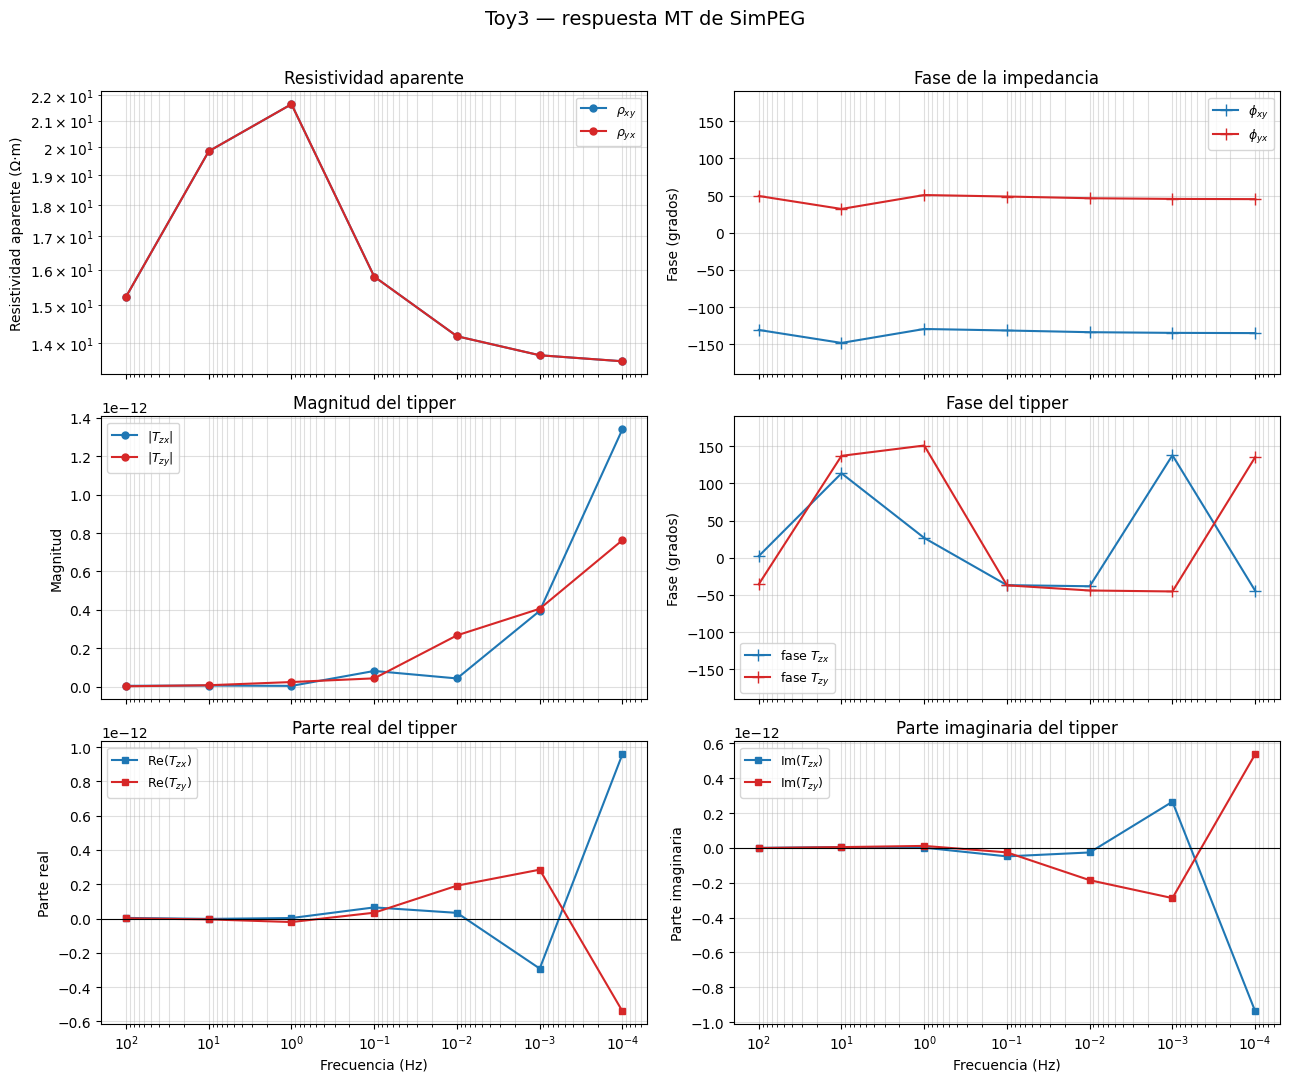

In [7]:
# 6) Figura unica: resistividad aparente, fase y tipper (SimPEG)
irec = 0
frec = frequency_list

c_xy, c_yx = "tab:blue", "tab:red"

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
(ax_rho, ax_phi), (ax_tmag, ax_tphi), (ax_treal, ax_timag) = axes

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy[irec], "-o", color=c_xy, markersize=5, label=r"$\rho_{xy}$")
ax_rho.plot(frec, rho_yx[irec], "-o", color=c_yx, markersize=5, label=r"$\rho_{yx}$")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.set_title("Resistividad aparente")

# --- Fase de la impedancia
ax_phi.plot(frec, phi_xy[irec], "-+", color=c_xy, markersize=9, label=r"$\phi_{xy}$")
ax_phi.plot(frec, phi_yx[irec], "-+", color=c_yx, markersize=9, label=r"$\phi_{yx}$")
ax_phi.set_ylim(-190, 190)
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_title("Fase de la impedancia")

# --- Magnitud del tipper
ax_tmag.plot(frec, mag_tzx[irec], "-o", color=c_xy, markersize=5, label=r"$|T_{zx}|$")
ax_tmag.plot(frec, mag_tzy[irec], "-o", color=c_yx, markersize=5, label=r"$|T_{zy}|$")
ax_tmag.set_ylabel("Magnitud")
ax_tmag.set_title("Magnitud del tipper")

# --- Fase del tipper
ax_tphi.plot(frec, phi_tzx[irec], "-+", color=c_xy, markersize=9, label=r"fase $T_{zx}$")
ax_tphi.plot(frec, phi_tzy[irec], "-+", color=c_yx, markersize=9, label=r"fase $T_{zy}$")
ax_tphi.set_ylim(-190, 190)
ax_tphi.set_ylabel("Fase (grados)")
ax_tphi.set_title("Fase del tipper")

# --- Parte real e imaginaria del tipper
ax_treal.plot(frec, np.real(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Re($T_{zx}$)")
ax_treal.plot(frec, np.real(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Re($T_{zy}$)")
ax_treal.set_ylabel("Parte real")
ax_treal.set_title("Parte real del tipper")

ax_timag.plot(frec, np.imag(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Im($T_{zx}$)")
ax_timag.plot(frec, np.imag(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Im($T_{zy}$)")
ax_timag.set_ylabel("Parte imaginaria")
ax_timag.set_title("Parte imaginaria del tipper")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(loc="best", fontsize=9)

for ax in (ax_treal, ax_timag):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Frecuencia (Hz)")

# El eje x es compartido: basta invertirlo una vez
ax_rho.invert_xaxis()

fig.suptitle("Toy3 — respuesta MT de SimPEG", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("SimPEG_Toy3.png", dpi=300, bbox_inches="tight")
plt.show()

## Notas

- `Simulation3DPrimarySecondary` resuelve el campo secundario sobre un primario analítico de
  semiespacio (`sigmaPrimary = sigBG`), por eso el modelo de fondo debe conservar las celdas de aire.
- A las frecuencias más bajas ($10^{-4}$ Hz) el *skin depth* supera el tamaño del dominio de
  `mesh_Toy3_MT.json` y la respuesta queda dominada por los bordes de la malla.

### Archivos generados

| Archivo | Contenido |
|---|---|
| `impedance_SimPEG_Toy3.npy` | tensor de impedancias `Z`, forma `(n_rec, n_freq, 2, 2)` |
| `tipper_SimPEG_Toy3.npy` | tipper `T`, forma `(n_rec, n_freq, 2)` |
| `SimPEG_Toy3.png` | resistividad aparente, fase y tipper de SimPEG |

## Comparación: operador MT3DZ vs. SimPEG

Comparación de las dos respuestas MT calculadas para el **mismo** modelo, la misma malla, las
mismas frecuencias y el mismo receptor.

| Fuente | Archivos | Cuaderno que los genera |
|---|---|---|
| Operador MT3DZ | `impedance_MT3DZ_Toy3.npy`, `tipper_MT3DZ_Toy3.npy` | `MT_ModelToy3_MT3DZ.ipynb` |
| SimPEG | `impedance_SimPEG_Toy3.npy`, `tipper_SimPEG_Toy3.npy` | este cuaderno (celdas anteriores) |

Esta sección **no vuelve a correr ningún modelamiento directo**: solo carga los `.npy`, compara
resistividad aparente, fase y tipper, y cuantifica la diferencia con MAE / RMSE / MAPE.

**Genera:** la figura `MT3DZ_vs_SimPEG_Toy3.png`.

> Requiere haber ejecutado antes `MT_ModelToy3_MT3DZ.ipynb`, que es el que escribe
> `impedance_MT3DZ_Toy3.npy` y `tipper_MT3DZ_Toy3.npy`.

In [8]:
# 7) Parametros y utilidades de la comparacion
#    Version general de las utilidades: en esta seccion cada componente llega como un vector
#    (n_freq,) de un unico receptor, no como una matriz (n_rec, n_freq).

# Receptor a comparar
irec = 0


def apparent_resistivity(Zcomp, frequencies):
    """Resistividad aparente a partir de una componente de Z."""
    omega = 2 * np.pi * np.asarray(frequencies)
    return np.abs(Zcomp) ** 2 / (mu_0 * omega)


def phase_deg(Zcomp):
    """Fase en grados."""
    return np.degrees(np.angle(Zcomp))

In [9]:
# 8) Carga de las dos respuestas

# Operador MT3DZ (Forward/MT3DZ.py -> compute_mt_responses)
impedance_op = np.load("impedance_MT3DZ_Toy3.npy")
tipper_op = np.load("tipper_MT3DZ_Toy3.npy")

# SimPEG (NSEM.Simulation3DPrimarySecondary)
impedance_sp = np.load("impedance_SimPEG_Toy3.npy")
tipper_sp = np.load("tipper_SimPEG_Toy3.npy")

print("Operador MT3DZ -> Z:", impedance_op.shape, "| T:", tipper_op.shape)
print("SimPEG         -> Z:", impedance_sp.shape, "| T:", tipper_sp.shape)
print("(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)")

assert impedance_op.shape == impedance_sp.shape, "Z: las formas no coinciden"
assert tipper_op.shape == tipper_sp.shape, "T: las formas no coinciden"
assert impedance_op.shape[1] == len(frequency_list), "n_freq no coincide con frequency_list"

Operador MT3DZ -> Z: (1, 7, 2, 2) | T: (1, 7, 2)
SimPEG         -> Z: (1, 7, 2, 2) | T: (1, 7, 2)
(n_rec, n_freq, 2, 2) y (n_rec, n_freq, 2)


In [10]:
# 9) Resistividad aparente, fase y tipper de cada operador

# Frecuencias de menor a mayor, para que las curvas queden conectadas
orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# --- Impedancia: componentes XY / YX
Zxy_op = impedance_op[irec, orden, 0, 1]
Zyx_op = impedance_op[irec, orden, 1, 0]

Zxy_sp = impedance_sp[irec, orden, 0, 1]
Zyx_sp = impedance_sp[irec, orden, 1, 0]

rho_xy_op = apparent_resistivity(Zxy_op, frec)
rho_yx_op = apparent_resistivity(Zyx_op, frec)
rho_xy_sp = apparent_resistivity(Zxy_sp, frec)
rho_yx_sp = apparent_resistivity(Zyx_sp, frec)

phi_xy_op = phase_deg(Zxy_op)
phi_yx_op = phase_deg(Zyx_op)
phi_xy_sp = phase_deg(Zxy_sp)
phi_yx_sp = phase_deg(Zyx_sp)

# --- Tipper: componentes Tzx / Tzy
Tzx_op = tipper_op[irec, orden, 0]
Tzy_op = tipper_op[irec, orden, 1]

Tzx_sp = tipper_sp[irec, orden, 0]
Tzy_sp = tipper_sp[irec, orden, 1]

mag_tzx_op, mag_tzy_op = np.abs(Tzx_op), np.abs(Tzy_op)
mag_tzx_sp, mag_tzy_sp = np.abs(Tzx_sp), np.abs(Tzy_sp)

phi_tzx_op, phi_tzy_op = phase_deg(Tzx_op), phase_deg(Tzy_op)
phi_tzx_sp, phi_tzy_sp = phase_deg(Tzx_sp), phase_deg(Tzy_sp)

# --- Diferencias relativas respecto a SimPEG (%)
dif_Z_xy = np.abs(Zxy_op - Zxy_sp) / np.abs(Zxy_sp) * 100
dif_Z_yx = np.abs(Zyx_op - Zyx_sp) / np.abs(Zyx_sp) * 100

dif_T_zx = np.abs(Tzx_op - Tzx_sp) / np.abs(Tzx_sp) * 100
dif_T_zy = np.abs(Tzy_op - Tzy_sp) / np.abs(Tzy_sp) * 100

# El operador deja NaN donde la matriz de campos magneticos queda mal condicionada
print("NaN en el operador MT3DZ -> Zxy:", np.isnan(Zxy_op).sum(),
      "| Zyx:", np.isnan(Zyx_op).sum(),
      "| Tzx:", np.isnan(Tzx_op).sum(),
      "| Tzy:", np.isnan(Tzy_op).sum())

NaN en el operador MT3DZ -> Zxy: 0 | Zyx: 0 | Tzx: 0 | Tzy: 0


In [11]:
# 10) Tablas de diferencia frecuencia por frecuencia

print("=" * 84)
print("IMPEDANCIA:  operador MT3DZ vs. SimPEG")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'|dZxy|/|Zxy| %':>15} {'|dZyx|/|Zyx| %':>15} |"
      f" {'|Zxy| MT3DZ':>13} {'|Zxy| SimPEG':>13}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_Z_xy[j]:15.4f} {dif_Z_yx[j]:15.4f} |"
          f" {np.abs(Zxy_op[j]):13.6e} {np.abs(Zxy_sp[j]):13.6e}")

print()
print("=" * 84)
print("TIPPER:  operador MT3DZ vs. SimPEG")
print("=" * 84)
print(f"{'f [Hz]':>10} | {'|dTzx|/|Tzx| %':>15} {'|dTzy|/|Tzy| %':>15} |"
      f" {'|Tzx| MT3DZ':>13} {'|Tzx| SimPEG':>13}")
print("-" * 84)
for j, f in enumerate(frec):
    print(f"{f:10.1e} | {dif_T_zx[j]:15.4f} {dif_T_zy[j]:15.4f} |"
          f" {mag_tzx_op[j]:13.6f} {mag_tzx_sp[j]:13.6f}")

IMPEDANCIA:  operador MT3DZ vs. SimPEG
    f [Hz] |  |dZxy|/|Zxy| %  |dZyx|/|Zyx| % |   |Zxy| MT3DZ  |Zxy| SimPEG
------------------------------------------------------------------------------------
   1.0e-04 |         24.5241         24.5241 |  1.287366e-04  1.033835e-04
   1.0e-03 |         24.0918         24.0918 |  4.079024e-04  3.287276e-04
   1.0e-02 |         22.7753         22.7753 |  1.297947e-03  1.057723e-03
   1.0e-01 |         19.0935         19.0935 |  4.185741e-03  3.531788e-03
   1.0e+00 |         11.4533         11.4533 |  1.400866e-02  1.307146e-02
   1.0e+01 |          4.5784          4.5784 |  3.798593e-02  3.959855e-02
   1.0e+02 |          5.5240          5.5240 |  1.078162e-01  1.096495e-01

TIPPER:  operador MT3DZ vs. SimPEG
    f [Hz] |  |dTzx|/|Tzx| %  |dTzy|/|Tzy| % |   |Tzx| MT3DZ  |Tzx| SimPEG
------------------------------------------------------------------------------------
   1.0e-04 |        111.6175         73.8130 |      0.000000      0.000000
   1.

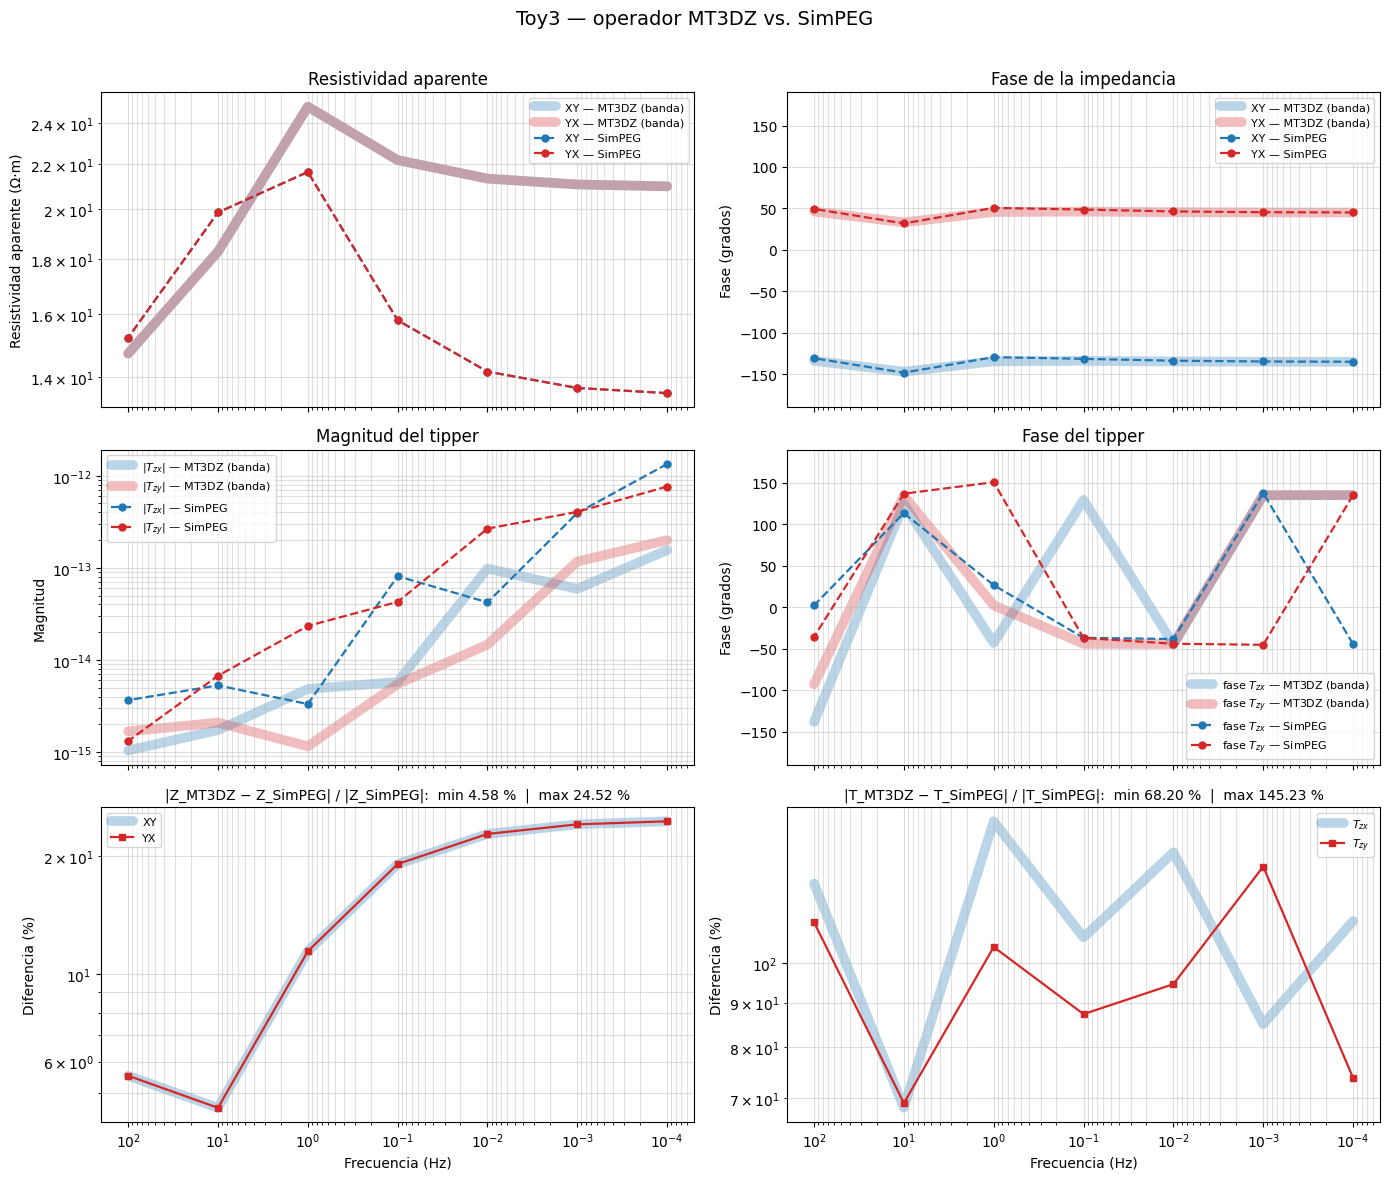

In [12]:
# 11) Figura unica de comparacion
#    Operador MT3DZ: banda gruesa translucida.  SimPEG: linea a guiones encima.
#    Donde SimPEG cae dentro de la banda, las dos soluciones coinciden.

c_xy, c_yx = "tab:blue", "tab:red"

kw_op = dict(linestyle="-", linewidth=7, alpha=0.30, solid_capstyle="round", zorder=1)
kw_sp = dict(linestyle="--", linewidth=1.6, marker="o", markersize=5, zorder=3)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
(ax_rho, ax_phi), (ax_tmag, ax_tphi), (ax_dz, ax_dt) = axes

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy_op, color=c_xy, label="XY — MT3DZ (banda)", **kw_op)
ax_rho.plot(frec, rho_yx_op, color=c_yx, label="YX — MT3DZ (banda)", **kw_op)
ax_rho.plot(frec, rho_xy_sp, color=c_xy, label="XY — SimPEG", **kw_sp)
ax_rho.plot(frec, rho_yx_sp, color=c_yx, label="YX — SimPEG", **kw_sp)
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.set_title("Resistividad aparente")

# --- Fase de la impedancia
ax_phi.plot(frec, phi_xy_op, color=c_xy, label="XY — MT3DZ (banda)", **kw_op)
ax_phi.plot(frec, phi_yx_op, color=c_yx, label="YX — MT3DZ (banda)", **kw_op)
ax_phi.plot(frec, phi_xy_sp, color=c_xy, label="XY — SimPEG", **kw_sp)
ax_phi.plot(frec, phi_yx_sp, color=c_yx, label="YX — SimPEG", **kw_sp)
ax_phi.set_ylim(-190, 190)
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_title("Fase de la impedancia")

# --- Magnitud del tipper
ax_tmag.plot(frec, mag_tzx_op, color=c_xy, label=r"$|T_{zx}|$ — MT3DZ (banda)", **kw_op)
ax_tmag.plot(frec, mag_tzy_op, color=c_yx, label=r"$|T_{zy}|$ — MT3DZ (banda)", **kw_op)
ax_tmag.plot(frec, mag_tzx_sp, color=c_xy, label=r"$|T_{zx}|$ — SimPEG", **kw_sp)
ax_tmag.plot(frec, mag_tzy_sp, color=c_yx, label=r"$|T_{zy}|$ — SimPEG", **kw_sp)
ax_tmag.set_yscale("log")
ax_tmag.set_ylabel("Magnitud")
ax_tmag.set_title("Magnitud del tipper")

# --- Fase del tipper
ax_tphi.plot(frec, phi_tzx_op, color=c_xy, label=r"fase $T_{zx}$ — MT3DZ (banda)", **kw_op)
ax_tphi.plot(frec, phi_tzy_op, color=c_yx, label=r"fase $T_{zy}$ — MT3DZ (banda)", **kw_op)
ax_tphi.plot(frec, phi_tzx_sp, color=c_xy, label=r"fase $T_{zx}$ — SimPEG", **kw_sp)
ax_tphi.plot(frec, phi_tzy_sp, color=c_yx, label=r"fase $T_{zy}$ — SimPEG", **kw_sp)
ax_tphi.set_ylim(-190, 190)
ax_tphi.set_ylabel("Fase (grados)")
ax_tphi.set_title("Fase del tipper")

# --- Diferencia relativa de la impedancia
ax_dz.plot(frec, dif_Z_xy, color=c_xy, label="XY", **kw_op)
ax_dz.plot(frec, dif_Z_yx, color=c_yx, marker="s", markersize=5, linewidth=1.6,
           linestyle="-", zorder=3, label="YX")
ax_dz.set_yscale("log")
ax_dz.set_ylabel("Diferencia (%)")
ax_dz.set_xlabel("Frecuencia (Hz)")
ax_dz.set_title(
    f"|Z_MT3DZ − Z_SimPEG| / |Z_SimPEG|:  min {np.nanmin([dif_Z_xy.min(), dif_Z_yx.min()]):.2f} %"
    f"  |  max {np.nanmax([dif_Z_xy.max(), dif_Z_yx.max()]):.2f} %",
    fontsize=10,
)

# --- Diferencia relativa del tipper
ax_dt.plot(frec, dif_T_zx, color=c_xy, label=r"$T_{zx}$", **kw_op)
ax_dt.plot(frec, dif_T_zy, color=c_yx, marker="s", markersize=5, linewidth=1.6,
           linestyle="-", zorder=3, label=r"$T_{zy}$")
ax_dt.set_yscale("log")
ax_dt.set_ylabel("Diferencia (%)")
ax_dt.set_xlabel("Frecuencia (Hz)")
ax_dt.set_title(
    f"|T_MT3DZ − T_SimPEG| / |T_SimPEG|:  min {np.nanmin([dif_T_zx.min(), dif_T_zy.min()]):.2f} %"
    f"  |  max {np.nanmax([dif_T_zx.max(), dif_T_zy.max()]):.2f} %",
    fontsize=10,
)

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(loc="best", fontsize=8)

# El eje x es compartido: basta invertirlo una vez
ax_rho.invert_xaxis()

fig.suptitle("Toy3 — operador MT3DZ vs. SimPEG", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("MT3DZ_vs_SimPEG_Toy3.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# 12) Metricas de error del operador MT3DZ respecto a SimPEG

def metricas_error(operador, simpeg, nombre="Variable", unidad="Ω·m"):
    """MAE, RMSE y MAPE descartando NaN, inf y valores de referencia casi nulos."""
    operador = np.asarray(operador, dtype=float)
    simpeg = np.asarray(simpeg, dtype=float)

    mask = (
        np.isfinite(operador)
        & np.isfinite(simpeg)
        & (np.abs(simpeg) > 1e-12)
    )

    n_desc = operador.size - mask.sum()

    error = operador[mask] - simpeg[mask]

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / simpeg[mask])) * 100

    print(f"\n{nombre}   (n={mask.sum()}, descartados={n_desc})")
    print(f"MAE  = {mae:.4f} {unidad}")
    print(f"RMSE = {rmse:.4f} {unidad}")
    print(f"MAPE = {mape:.2f} %")

    return mae, rmse, mape


print("=" * 60)
print("RESISTIVIDAD APARENTE")
print("=" * 60)
metricas_error(rho_xy_op, rho_xy_sp, nombre="Resistividad aparente XY")
metricas_error(rho_yx_op, rho_yx_sp, nombre="Resistividad aparente YX")

print("\n" + "=" * 60)
print("FASE")
print("=" * 60)
metricas_error(phi_xy_op, phi_xy_sp, nombre="Fase XY", unidad="grados")
metricas_error(phi_yx_op, phi_yx_sp, nombre="Fase YX", unidad="grados")

print("\n" + "=" * 60)
print("TIPPER (magnitud)")
print("=" * 60)
metricas_error(mag_tzx_op, mag_tzx_sp, nombre="|Tzx|", unidad="")
metricas_error(mag_tzy_op, mag_tzy_sp, nombre="|Tzy|", unidad="")

RESISTIVIDAD APARENTE

Resistividad aparente XY   (n=7, descartados=0)
MAE  = 4.8147 Ω·m
RMSE = 5.5477 Ω·m
MAPE = 32.32 %

Resistividad aparente YX   (n=7, descartados=0)
MAE  = 4.8147 Ω·m
RMSE = 5.5477 Ω·m
MAPE = 32.32 %

FASE

Fase XY   (n=7, descartados=0)
MAE  = 1.8469 grados
RMSE = 2.4521 grados
MAPE = 1.40 %

Fase YX   (n=7, descartados=0)
MAE  = 1.8469 grados
RMSE = 2.4521 grados
MAPE = 3.93 %

TIPPER (magnitud)

|Tzx|   (n=1, descartados=6)
MAE  = 0.0000 
RMSE = 0.0000 
MAPE = 88.38 %

|Tzy|   (n=0, descartados=7)
MAE  = nan 
RMSE = nan 
MAPE = nan %


/home/carlos-mogollon/anaconda3/envs/P8091/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/carlos-mogollon/anaconda3/envs/P8091/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(np.float64(nan), np.float64(nan), np.float64(nan))

### Cómo leer la comparación

- El **operador MT3DZ** se dibuja como banda gruesa translúcida y **SimPEG** como línea a guiones
  encima: donde SimPEG cae dentro de la banda, las dos soluciones coinciden.
- La fila inferior es la **diferencia relativa respecto a SimPEG** (%), en escala logarítmica.
- La diferencia crece hacia las **frecuencias bajas**: a $10^{-4}$ Hz el *skin depth* supera con
  holgura el tamaño del dominio de `mesh_Toy3_MT.json`, así que la respuesta queda dominada por los
  bordes. Es un límite de la **malla**, no una discrepancia de formulación: para comparar a esas
  frecuencias hay que agrandar el dominio y el *padding*.
- En el **tipper** conviene mirar además la magnitud absoluta: cuando $|T|$ es muy pequeño, un
  error relativo grande sigue siendo un error absoluto diminuto.

### Archivos generados por la comparación

| Archivo | Contenido |
|---|---|
| `MT3DZ_vs_SimPEG_Toy3.png` | comparación de resistividad aparente, fase y tipper |